# v3 DF26: Monte-Carlo recovery (Figs V1/V2)

End-to-end DF26 recovery (Sec 12.2): train Block-1 networks, collect (parameter, moments) data, train the moment surrogates, recover parameters by Levenberg-Marquardt, and plot Fig V1 (moments) and Fig V2 (parameters).

One knob, `PROFILE`, sets the scale (all knobs live in `src/v3/profiles.py`); the code path is identical at every scale.

### Scale and cost

| profile | grids (state / control) | sim (firms × T) | collect rows | train epochs | use |
|---|---|---|---|---|---|
| `SMOKE`  | 5×5×7 / 9×9×7        | 300 × 50    | 32     | 6    | tests, seconds |
| `MEDIUM` | 7×10×15 / 25×25×15  | 2000 × 120  | 400    | 30   | M1 / CPU, minutes |
| `LARGE`  | 9×12×22 / 41×45×31  | 4000 × 250  | 2500   | 120  | A100, ~3 h, first findings |
| `FULL`   | 11×15×35 / 81×91×71 | 5000 × 300  | 10000  | 1000 | A100, ~1 day, paper replication |

### Estimation and surrogate

| profile | surrogate passes × hidden | recovery draws | LM restarts |
|---|---|---|---|
| `SMOKE`  | 40 × 32   | 4  | 6  |
| `MEDIUM` | 200 × 32  | 20 | 30 |
| `LARGE`  | 800 × 32  | 80 | 30 |
| `FULL`   | 200 × 32  | 40 | 30 |

What these control:

- **collect rows**: number of (parameter, moment) examples the surrogate learns from. More rows cover the 8-D parameter box better. This is the main collection cost.
- **surrogate passes**: training epochs over those rows. Total surrogate training is `passes × rows`. LARGE uses 800 so its surrogate gets the same total training as FULL (200 × 10000), because LARGE has fewer rows.
- **surrogate hidden**: width of the surrogate's 3 hidden layers, i.e. its capacity to represent curved moment surfaces. Held at 32 (the spec value).
- **recovery draws**: number of Monte-Carlo draws behind Figs V1/V2. It is the number of points in each panel, so more draws give more reliable R^2. LARGE uses 80 (FULL 40) since its smaller grid leaves room to spend more on draws.
- **LM restarts**: random restarts of the parameter search per fold. More restarts is more robust to local minima.
- **train epochs**: Block-1 network training length.

Fixed or speed-only (not results knobs):

- **collect batch size**: how many draws are solved at once. Affects GPU speed and memory only, not the results (SMOKE 8, MEDIUM and FULL 16, LARGE 64). LARGE's batch is sized for an 80 GB A100; lower it on a smaller card.
- **CV folds**: the surrogate always uses 10 cross-validation folds; this sets the across-fold confidence-interval width. Fixed, not a profile knob.
- **refine rounds**: solver policy-refinement rounds, 6 everywhere.

`device="auto"` uses the GPU on CUDA (Colab) and the CPU on Apple Metal.

**Setup**

- v3 needs only `tensorflow` + `numpy`, both preinstalled on Colab.
- The setup cell clones the repo and adds it to the path: it installs nothing and never restarts.
- In VS Code, pick the `.venv` kernel (CPU/M1) or a Colab GPU kernel; everything else auto-adapts.

In [1]:
import os
import platform

# Legacy Keras helps only on Apple Silicon (faster legacy Adam); set before importing TF. On
# Colab/CUDA, v3 uses native Keras. v3 depends only on tensorflow + numpy (no TFP), so the Colab
# setup needs no version pinning, no NumPy downgrade, and no runtime restart.
if platform.system() == "Darwin" and platform.machine() == "arm64":
    os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = "https://github.com/zhaoxuanwang/deep-learning-corp-finance.git"
    BRANCH = "v3"
    REPO_ROOT = "/content/deep-learning-corp-finance"
    if not os.path.exists(REPO_ROOT):
        # Public repo works as-is. Private repo: put a token in REPO_URL, e.g.
        #   REPO_URL = "https://<GITHUB_TOKEN>@github.com/zhaoxuanwang/deep-learning-corp-finance.git"
        !git clone --branch {BRANCH} --depth 1 {REPO_URL} {REPO_ROOT}
    # This notebook installs NOTHING on Colab (v3 needs only the preinstalled tensorflow + numpy).
    # Health check: if a PREVIOUS run pip-installed packages, that poisons the VM permanently
    # (pip changes survive a kernel restart), so importing TF fails. The fix is a full VM reset.
    try:
        import tensorflow as _tf  # noqa: F401
    except Exception as _e:
        raise SystemExit(
            "\nColab VM has a broken TensorFlow / NumPy / ml_dtypes environment, almost certainly "
            "from an EARLIER run that pip-installed packages (those changes survive a kernel restart, "
            "a restart is NOT enough).\n\nFIX: Runtime menu -> 'Disconnect and delete runtime' "
            "(factory reset), reconnect to a fresh A100, then run this cell again. This notebook "
            "installs nothing, so a fresh VM stays clean.\n"
        ) from _e
else:
    REPO_ROOT = os.getcwd()
    while REPO_ROOT != os.path.dirname(REPO_ROOT) and not os.path.isdir(os.path.join(REPO_ROOT, "src", "v3")):
        REPO_ROOT = os.path.dirname(REPO_ROOT)

import sys
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print("repo root:", REPO_ROOT, "| Colab:", IN_COLAB)

Cloning into '/content/deep-learning-corp-finance'...
remote: Enumerating objects: 383, done.
remote: Counting objects: 100% (383/383), done.
remote: Compressing objects: 100% (362/362), done.
remote: Total 383 (delta 18), reused 275 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (383/383), 11.92 MiB | 33.43 MiB/s, done.
Resolving deltas: 100% (18/18), done.
repo root: /content/deep-learning-corp-finance | Colab: True


In [2]:
# Confirm the device before a long run: on a Colab GPU runtime this prints the A100; locally it is CPU.
# device="auto" runs the float64 numerics on the GPU under CUDA, on the CPU otherwise.
import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
names = []
for g in gpus:
    try:
        names.append(tf.config.experimental.get_device_details(g).get("device_name", g.name))
    except Exception:
        names.append(g.name)
print("GPUs visible to TensorFlow:", names or "none (CPU only)")
print("device='auto' will use:", "GPU (float64 on device)" if gpus else "CPU")

GPUs visible to TensorFlow: ['NVIDIA A100-SXM4-80GB']
device='auto' will use: GPU (float64 on device)


**Run**

- Sets `PROFILE`, runs the full recovery, and saves every output under `RESULTS_ROOT`.
- Crash recovery: if the runtime disconnects mid-run (common on long Colab jobs), just re-run this cell. It auto-resumes from a checkpoint written before the recovery loop, skipping Block-1 training and data collection (the slow parts), and finishes the remaining draws.
- This relies on `RESULTS_ROOT` being on Google Drive (set above) so the checkpoint survives the runtime. The checkpoint is removed automatically once the run completes; changing the profile, seed, or grid starts fresh.

In [3]:
# Bootstrap: make the repo importable and define IN_COLAB / REPO_ROOT, even if the setup cell
# above was not run in this kernel (cells run out of order). Idempotent.
import os, sys
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
    REPO_ROOT = "/content/deep-learning-corp-finance"
    if not os.path.isdir(os.path.join(REPO_ROOT, "src")):
        get_ipython().system("git clone --branch v3 --depth 1 "
                             "https://github.com/zhaoxuanwang/deep-learning-corp-finance.git " + REPO_ROOT)
except ImportError:
    IN_COLAB = False
    REPO_ROOT = os.getcwd()
    while REPO_ROOT != os.path.dirname(REPO_ROOT) and not os.path.isdir(os.path.join(REPO_ROOT, "src", "v3")):
        REPO_ROOT = os.path.dirname(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
from src.v3.run import train_and_recover
from src.v3.validation import figures

PROFILE = "LARGE"   # "SMOKE" | "MEDIUM" | "LARGE" (~8h A100) | "FULL" (spec, ~days)

# Where every output is saved (figures, R^2 tables, arrays, network + surrogate checkpoints),
# so an expensive run never has to be repeated just to recover its outputs. On Colab, point
# this at Google Drive so it survives the runtime being recycled.
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    RESULTS_ROOT = "/content/drive/MyDrive/df26_v3_outputs"
else:
    RESULTS_ROOT = os.path.join(REPO_ROOT, "outputs", "v3")

out = train_and_recover(profile=PROFILE, device="auto", results_root=RESULTS_ROOT, verbose=True)
print("artifacts saved to:", out["run_dir"])


Mounted at /content/drive
[v3] recover | profile=LARGE device=gpu states=2376 train_epochs=120 collect_rows=2500 batch=64 draws=80 surrogate=800x32 restarts=30
  recovery draw 1/80 (attempt 1)
  recovery draw 2/80 (attempt 2)
  recovery draw 3/80 (attempt 5)
  recovery draw 4/80 (attempt 6)
  recovery draw 5/80 (attempt 9)
  recovery draw 6/80 (attempt 12)
  recovery draw 7/80 (attempt 13)
  recovery draw 8/80 (attempt 14)
  recovery draw 9/80 (attempt 17)
  recovery draw 10/80 (attempt 18)
  recovery draw 11/80 (attempt 20)
  recovery draw 12/80 (attempt 23)
  recovery draw 13/80 (attempt 24)
  recovery draw 14/80 (attempt 26)
  recovery draw 15/80 (attempt 28)
  recovery draw 16/80 (attempt 29)
  recovery draw 17/80 (attempt 30)
  recovery draw 18/80 (attempt 31)
  recovery draw 19/80 (attempt 32)
  recovery draw 20/80 (attempt 33)
  recovery draw 21/80 (attempt 34)
  recovery draw 22/80 (attempt 35)
  recovery draw 23/80 (attempt 37)
  recovery draw 24/80 (attempt 38)
  recovery dra

In [4]:
print(f"device={out['device']} | profile={out['profile']} | kept draws={out['true_beta'].shape[0]}")
print("surrogate OOS R^2 (mean):", round(float(np.mean(out["surrogate_oos_r2"])), 3))
print("moment   R^2 (mean):", round(float(np.mean(out["moment_r2"])), 3), "  (Fig V1 gate: >= 0.99 at FULL)")
print("param    R^2:", dict(zip(figures.PARAM_NAMES, np.round(out["param_r2"], 3))))
print("           (Fig V2 gate: >= 0.95 for >= 7/8 params; chi is the weak one)")

device=gpu | profile=LARGE | kept draws=80
surrogate OOS R^2 (mean): 0.614
moment   R^2 (mean): 0.504   (Fig V1 gate: >= 0.99 at FULL)
param    R^2: {'theta': np.float64(0.35), 'rho': np.float64(0.026), 'sigma': np.float64(0.479), 'delta': np.float64(0.535), 'gamma1': np.float64(0.136), 'gamma0': np.float64(0.074), 'chi': np.float64(0.348), 'cf': np.float64(0.424)}
           (Fig V2 gate: >= 0.95 for >= 7/8 params; chi is the weak one)


### Reading the plots and tables

- R² is the squared correlation between true and fitted, in [0, 1] (1 = perfect tracking).
- R² ignores bias and scale: read those from the fixed-range 45° plots and the CSV bias / RMSE.
- Moment CI = firm-clustered SE; parameter CI = across-fold SD of the estimate.
- A wide parameter CI or low R² (e.g. `chi`, `gamma0`) means weak identification, not a bug.
- Identified parameters tighten with more `collect_rows` (a better surrogate); weakly identified ones stay wide.

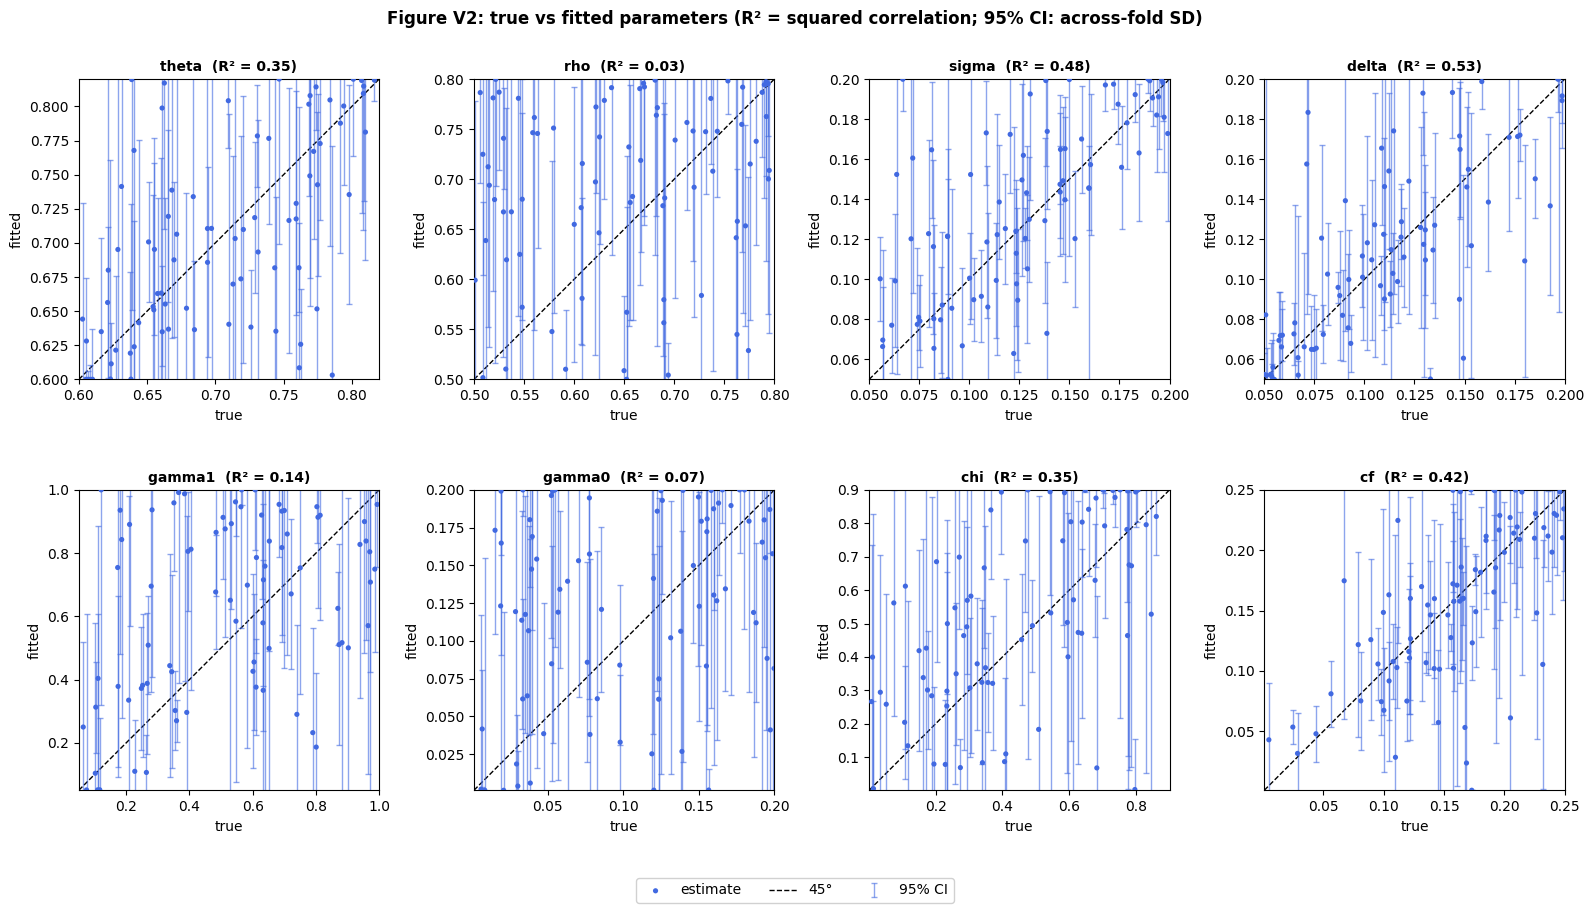

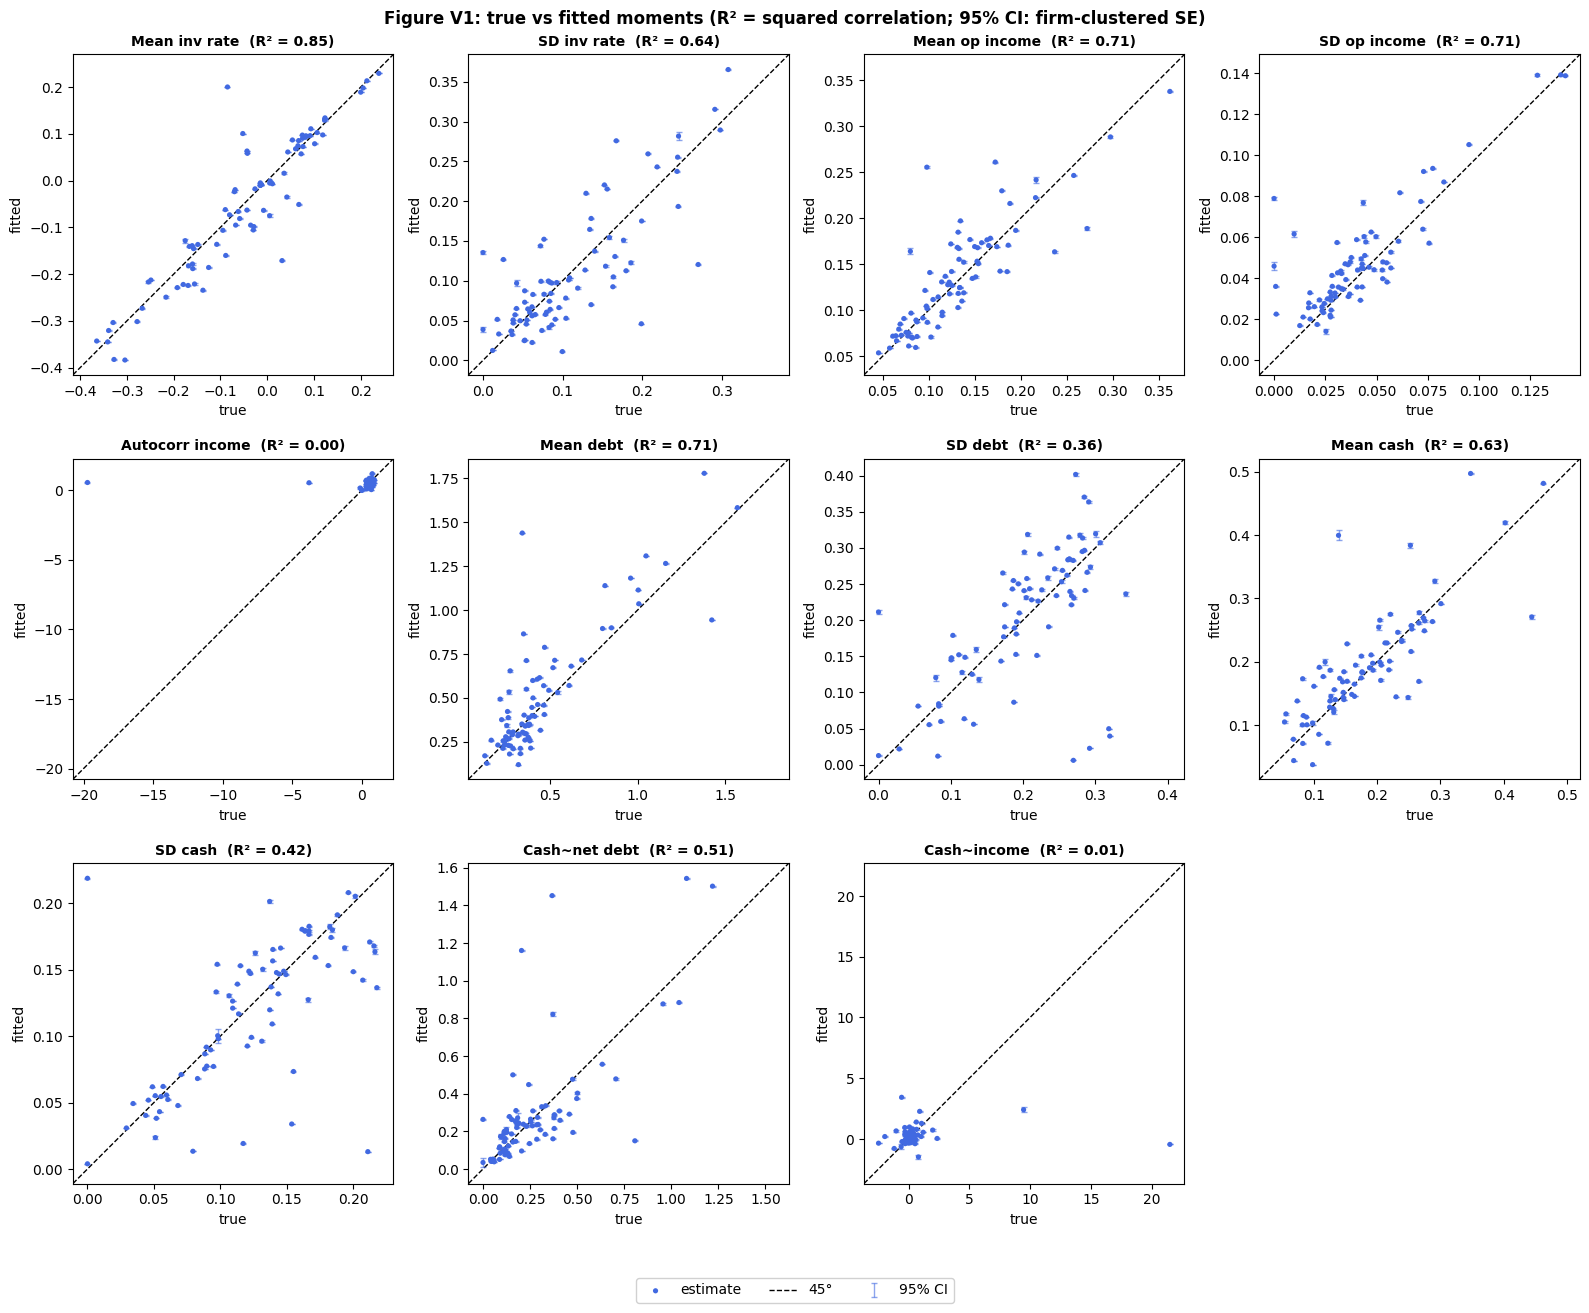

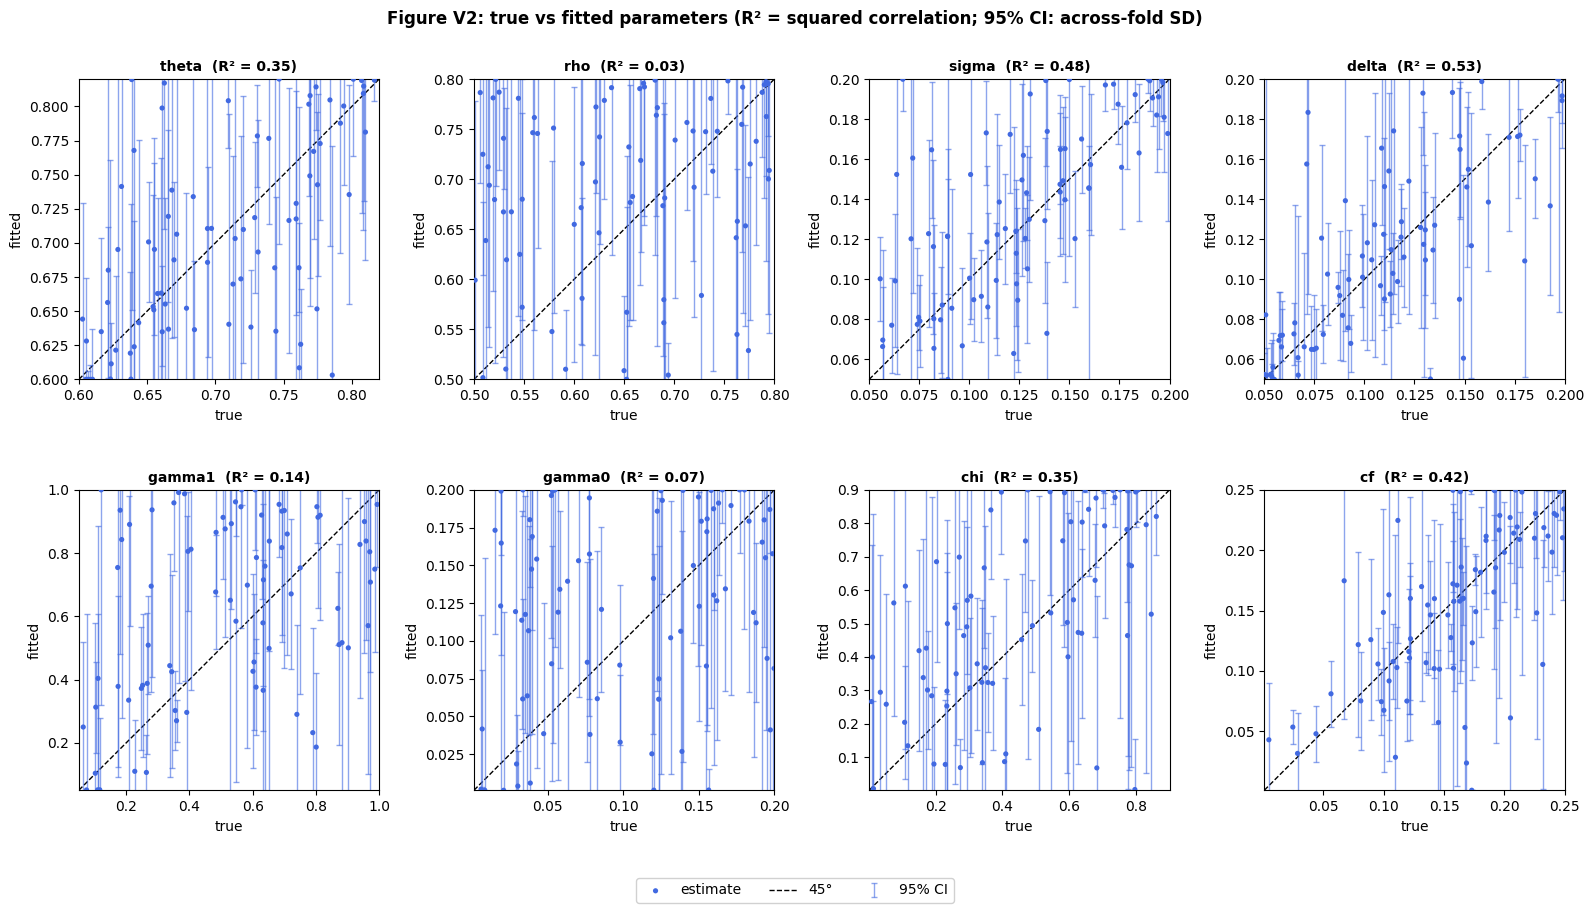

In [5]:
# Figures V1 (moments) and V2 (parameters) from this run.
# (Both are also saved to run_dir/figures by the run above; this just displays them.)
figures.plot_recovery_moments(out)
figures.plot_recovery_params(out)

In [6]:
# The figures, R^2 tables, arrays, and checkpoints are already saved under run_dir by the run above.
# To regenerate them LATER without re-running the expensive recovery, reload a saved run and call the
# same plot functions (no need to re-plot here):
from src.v3.output.artifacts import load_recovery

reloaded = load_recovery(out["run_dir"])   # or any past run_dir / Drive path
print("reloaded", reloaded["true_beta"].shape[0], "draws; "
      "figures.plot_recovery_moments(reloaded) / plot_recovery_params(reloaded) redraw without rerun.")
# The trained network + surrogate are checkpointed (bundle_ckpt / surrogate_ckpt) and the collected
# dataset is in arrays/dataset.npz, so you can re-estimate or extend without re-collecting.

reloaded 80 draws; figures.plot_recovery_moments(reloaded) / plot_recovery_params(reloaded) redraw without rerun.


Block 1 diagnostics (slices vs k/b/z + comparative statics) saved to /content/drive/MyDrive/df26_v3_outputs/df26_recovery/LARGE_20260621_044144/figures


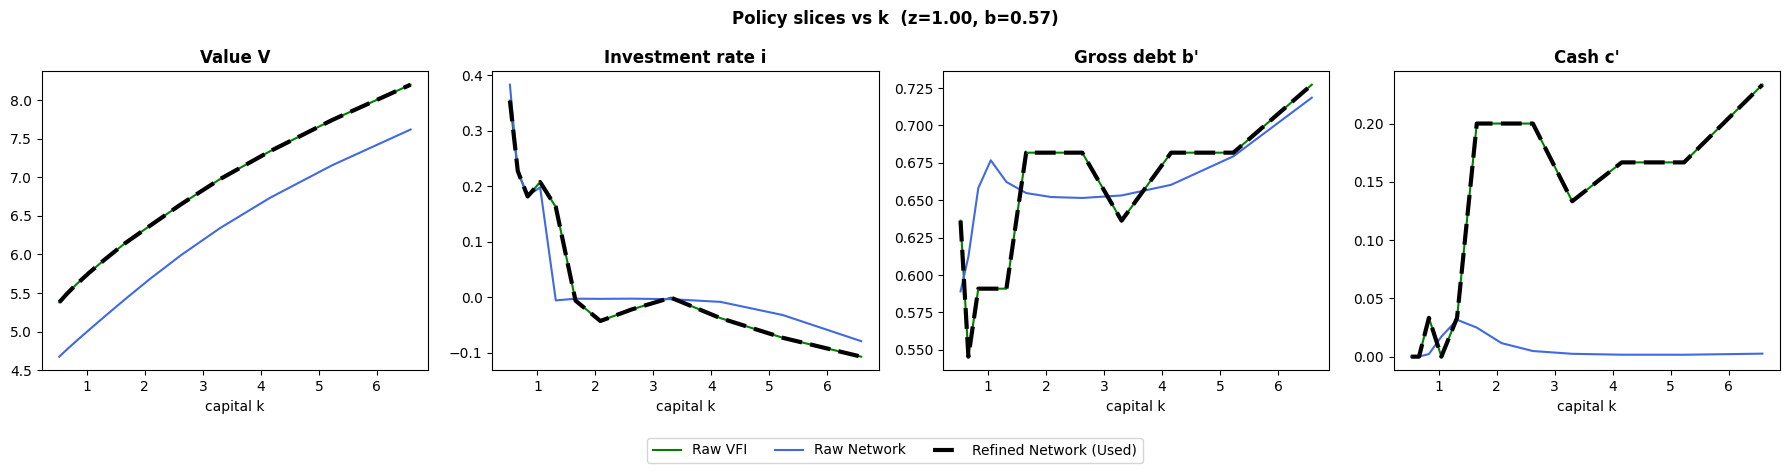

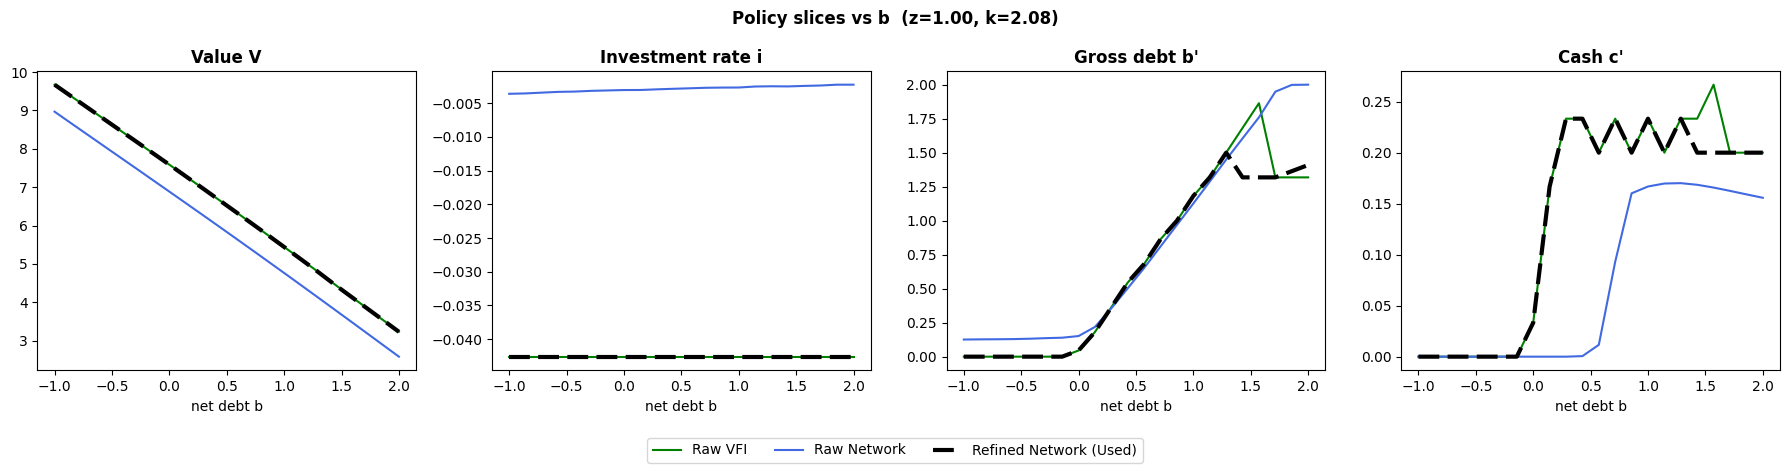

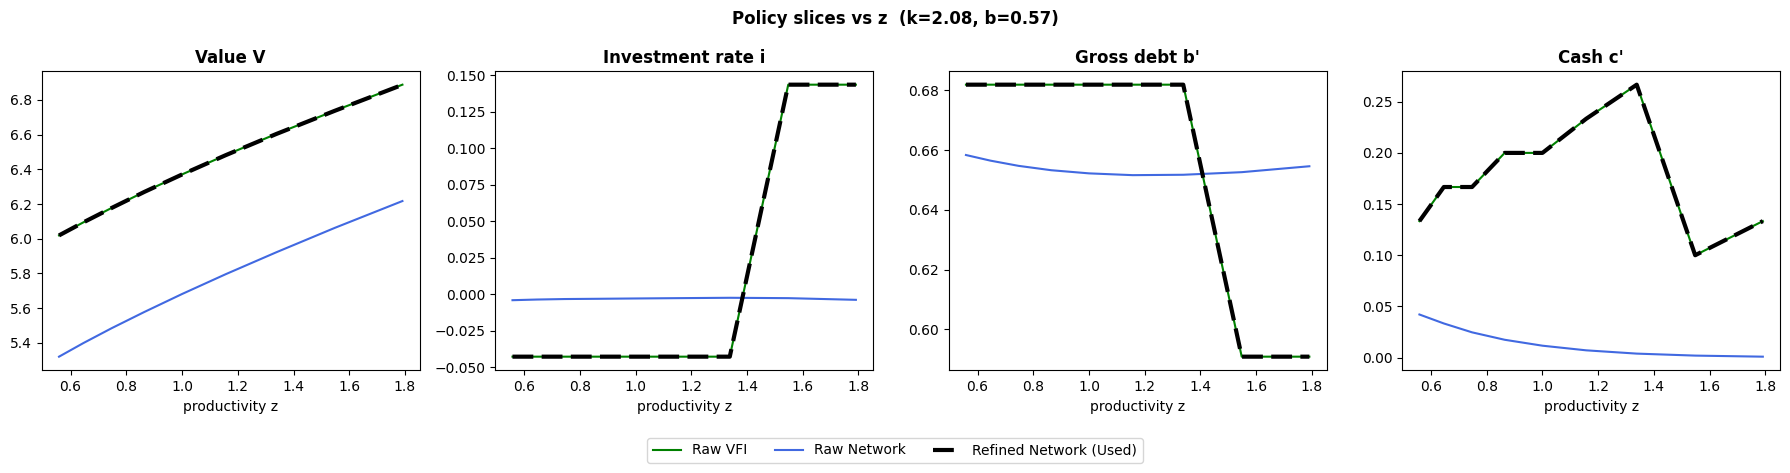

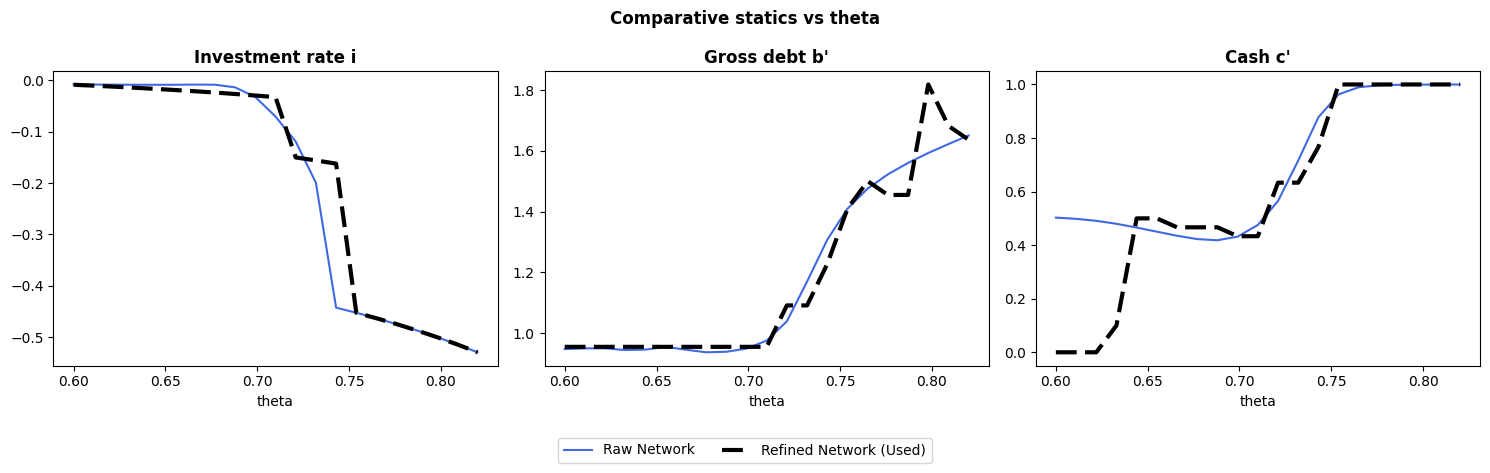

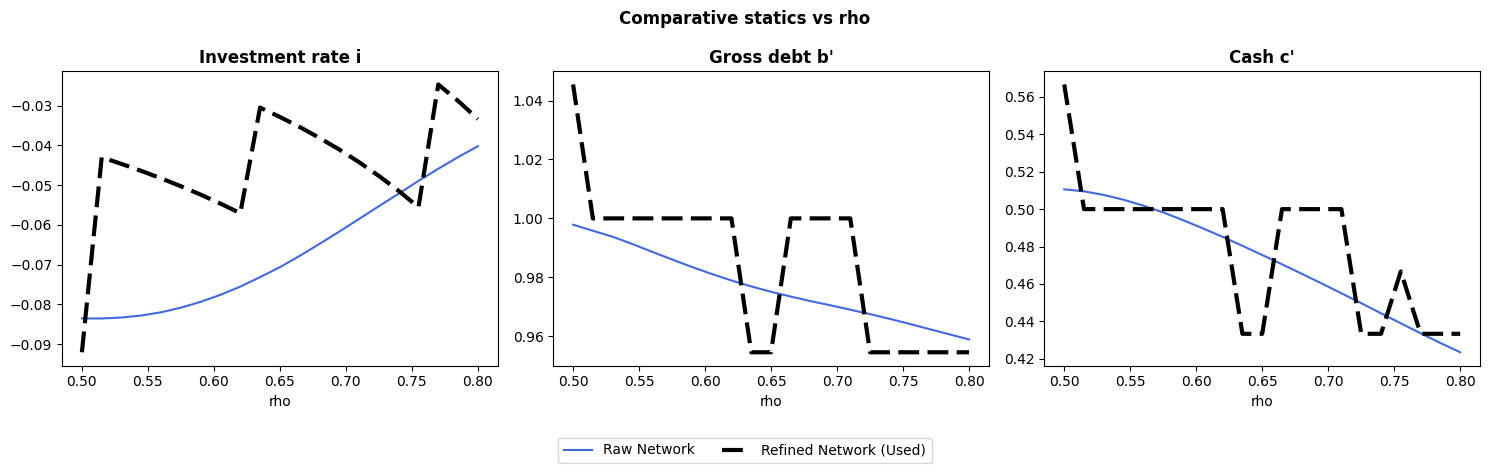

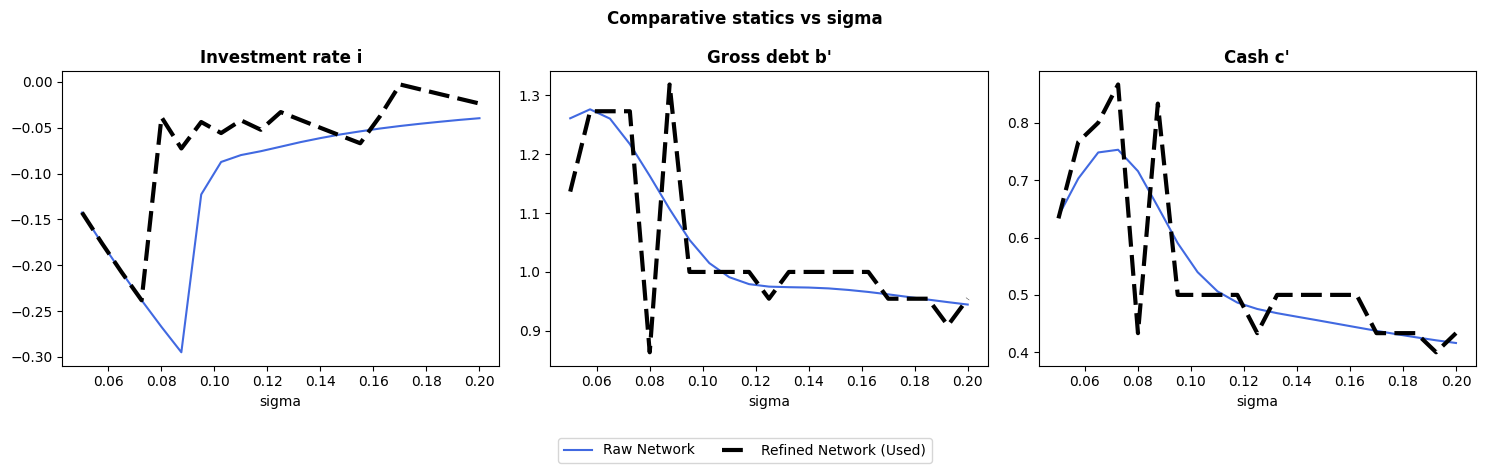

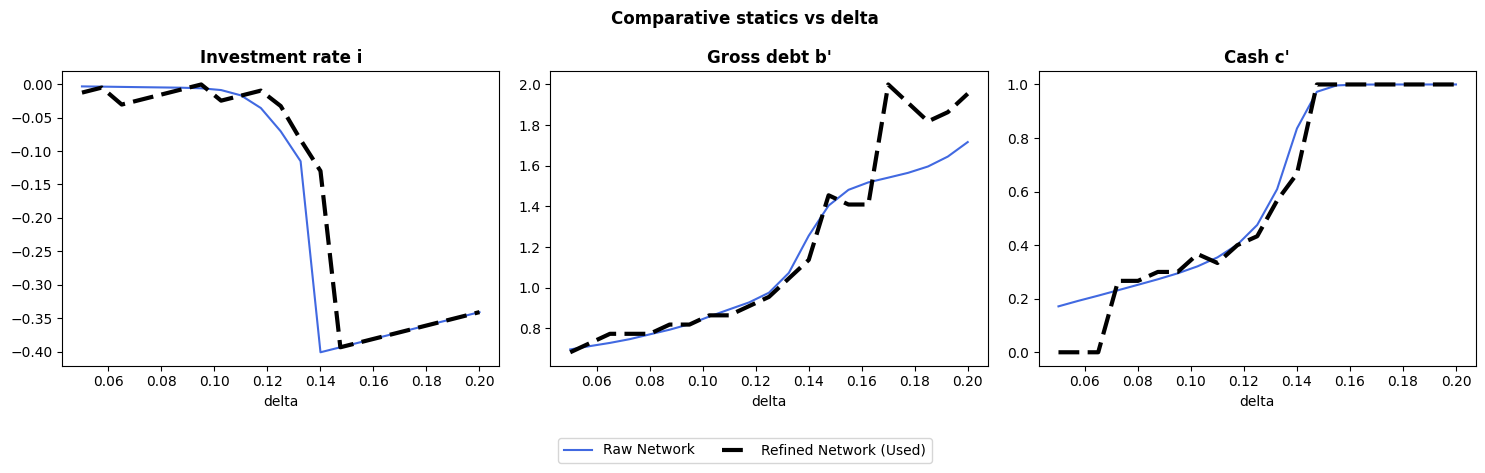

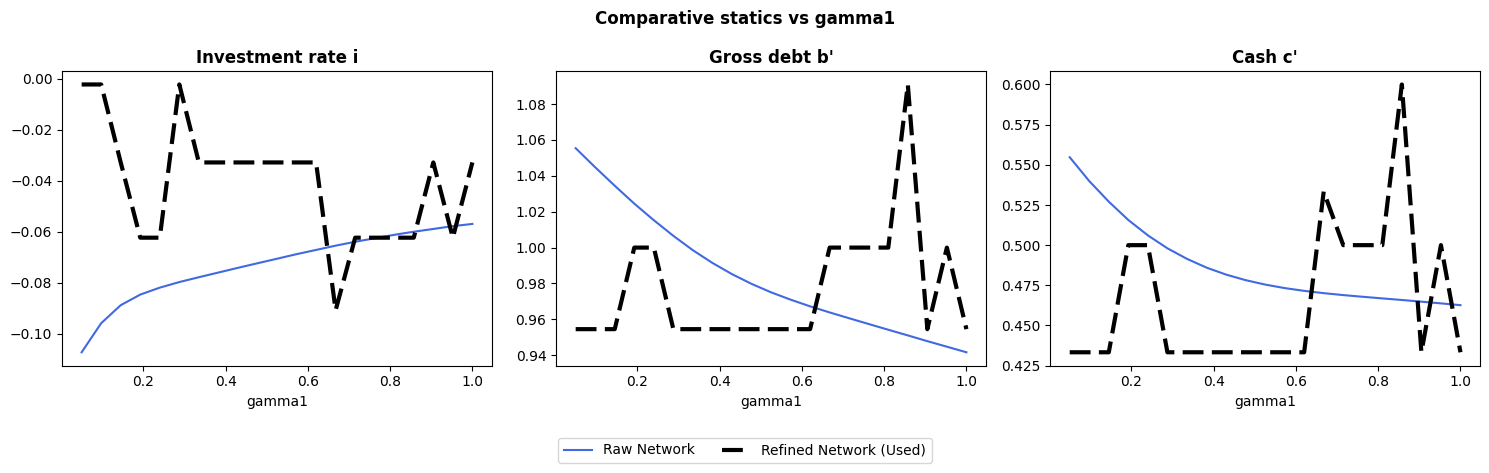

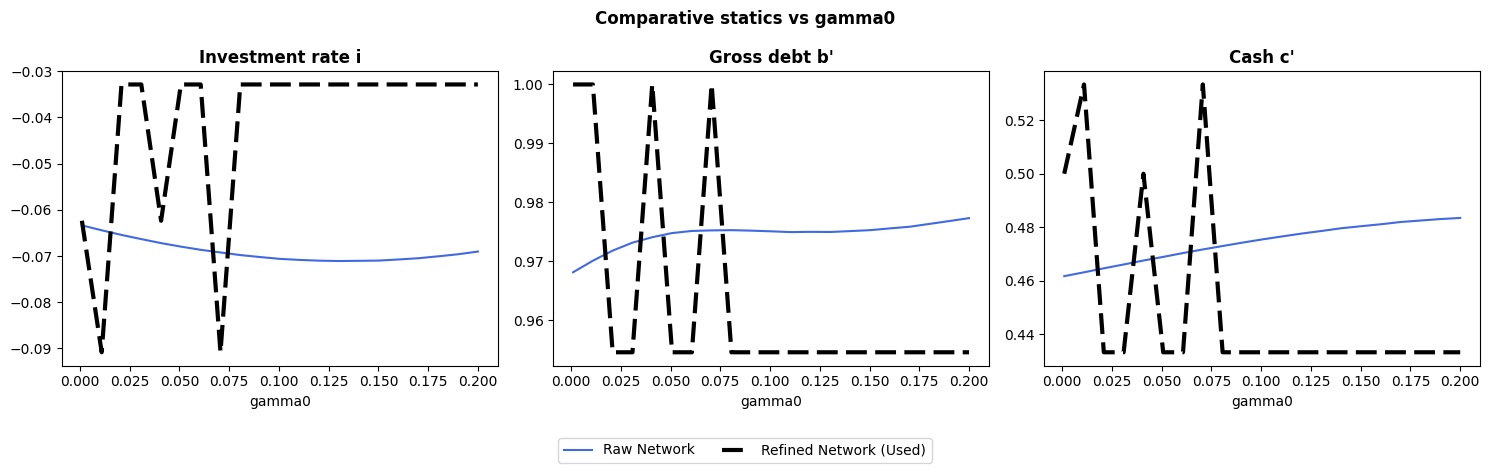

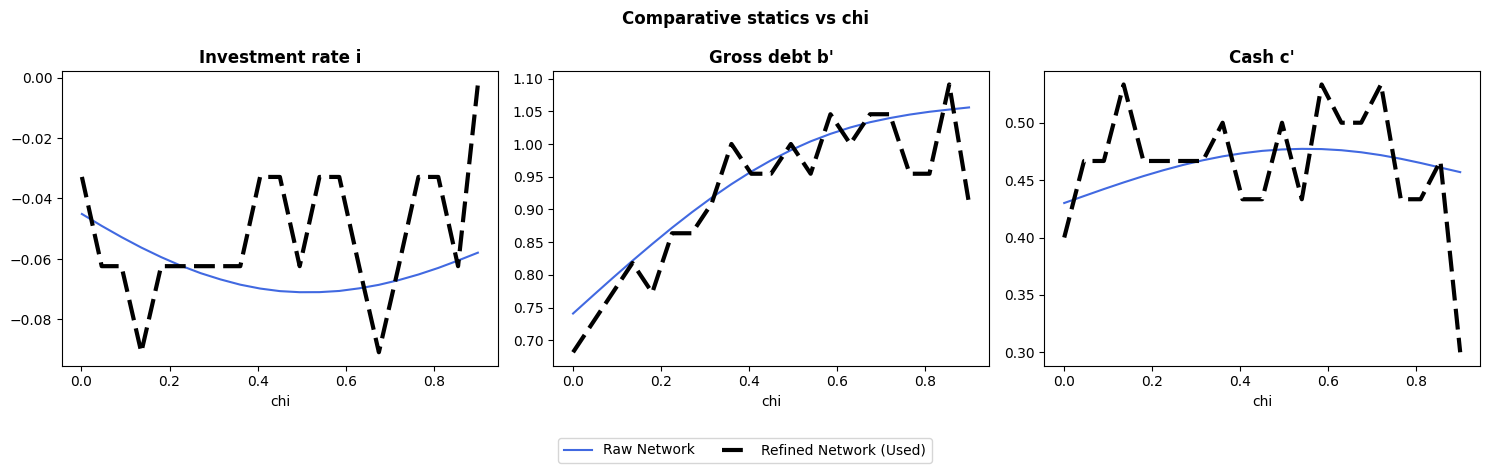

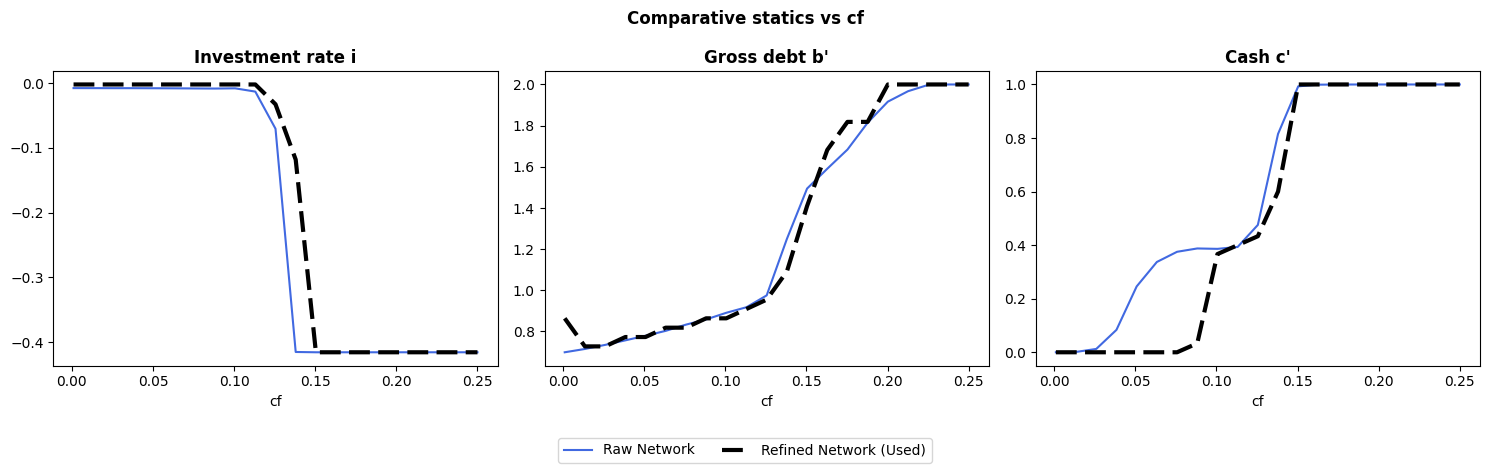

In [7]:
# Block 1 diagnostics from the trained network (latest Block 1 output): complete policy slices
# vs k, b, z, and comparative statics per parameter. Saved next to the recovery artifacts.
# Note: at FULL this adds one VFI solve + a batched refine per parameter; lower n_points to trim cost.
import os
from src.v3 import config as cfg
from src.v3.solver import refine as _refine
from src.v3.validation import vfi as _vfi, evaluate as _ev, policy_slices, comparative

bundle, GRID = out["bundle"], out["grid"]
EXT, BOUNDS, PARAMS = cfg.ExternalParams(), cfg.ParamBounds.table_a1(), cfg.REFERENCE_ESTIMATES
fig_dir = os.path.join(out["run_dir"], "figures")

vfi_sol = _vfi.solve_vfi(PARAMS, EXT, GRID, mode="howard", tol=1e-8, max_sweeps=200)
refined = _refine.refine(bundle, PARAMS, EXT, GRID, BOUNDS, n_rounds=6)
net = _ev.network_on_grid(bundle, PARAMS, EXT, GRID, BOUNDS)

for ax in ("k", "b", "z"):   # raw VFI (thick dash) / NN (blue) / refined NN (bold red, used)
    figures.plot_policy_slices(policy_slices.slices(vfi_sol, net, refined, axis=ax),
                               savepath=os.path.join(fig_dir, f"fig_v3_slices_{ax}.png"))
for pname in cfg.PARAM_NAMES:   # one 1x3 (i, b', c') per parameter, NN + refined NN
    figures.plot_comparative_statics(
        comparative.comparative_statics(bundle, pname, BOUNDS, EXT, GRID, n_points=21),
        savepath=os.path.join(fig_dir, f"fig_comparative_{pname}.png"))
print("Block 1 diagnostics (slices vs k/b/z + comparative statics) saved to", fig_dir)

## Notes

**Acceptance gates (Sec 12.2)**

- Fig V1: moment R² ≥ 0.99.
- Fig V2: parameter R² ≥ 0.95 for ≥ 7 of 8.
- Reached at `FULL`; `LARGE` lands in the right region for first findings.

**GPU choice (LARGE / FULL)**

- Use an A100 (Colab Pro+): the float64 solves need a datacenter GPU; T4 / L4 cripple float64.
- 40 GB fits `collect_batch_size=16`; raise to 24-32 on an 80 GB A100.

**Timing (measured on A100)**

- `LARGE` ≈ 3 h; `FULL` ≈ ~1 day, collection-dominated.
- Biggest levers: `collect_rows` (surrogate accuracy), then `train_epochs`.
- Override per run, e.g. `train_and_recover("FULL", recovery_draws=4)`.

**Outputs**

- Figures, CSV tables, arrays, and checkpoints save under `run_dir` (Drive on Colab).
- Reload later with `load_recovery(run_dir)`; no re-run needed.
- Adaptive controller (Sec 6) demo: `from src.v3.run import run_adaptive_controller`.